Connecting Green Clusters to Residents: 100%|████████████████████████████████████████| 13/13 [00:00<00:00, 3231.17it/s]


Filtered Valid Critical Points Bounds:
[92.687265   20.66666667 94.08333333 24.1008892 ]


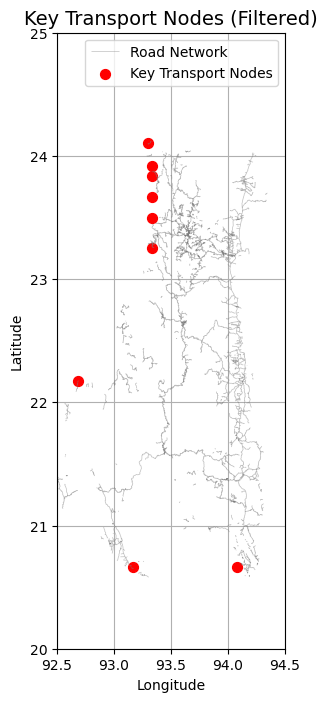

🚛 有效关键运输枢纽点 (经纬度):
                    geometry  longitude   latitude
1  POINT (93.29944 24.10089)  93.299439  24.100889
2  POINT (92.68726 22.17556)  92.687265  22.175555
3  POINT (93.33333 23.66667)  93.333333  23.666667
4  POINT (93.33333 23.50000)  93.333333  23.500000
5  POINT (93.33333 23.25000)  93.333333  23.250000
6  POINT (93.16667 20.66667)  93.166667  20.666667
7  POINT (93.33333 23.91667)  93.333333  23.916667
8  POINT (93.33333 23.83333)  93.333333  23.833333
9  POINT (94.08333 20.66667)  94.083333  20.666667


In [17]:
import rasterio
import numpy as np
import geopandas as gpd
import networkx as nx
from shapely.geometry import LineString, MultiLineString, Point
from scipy.spatial import KDTree
from scipy.ndimage import label
from tqdm import tqdm
import matplotlib.pyplot as plt

# **1. 读取粮食产值栅格**
crop_tif = "E:/paper/Political Georaphy/Food/Bean/spam2020V1r0_global_production/spam2020_v1r0_global_P_mg_A.tif"
with rasterio.open(crop_tif) as crop_src:
    crop_data = crop_src.read(1)
    crop_transform = crop_src.transform

# **2. 读取居民点栅格**
settlement_tif = "E:/paper/Political Georaphy/Food/accessbility/settlement_raster.tif"
with rasterio.open(settlement_tif) as settlement_src:
    settlement_data = settlement_src.read(1)

# **3. 读取路网数据**
road_shp = "E:/paper/Political Georaphy/Food/accessbility/Logisticsroad.shp"
roads = gpd.read_file(road_shp)

# **4. 获取绿色栅格 (>100t)、居民点和路网节点**
green_mask = crop_data > 100
resident_positions = np.column_stack(np.where(settlement_data == 1))

# 将路网提取为坐标点
road_nodes = []
for _, road in roads.iterrows():
    geom = road.geometry
    if isinstance(geom, LineString):
        road_nodes.extend(list(geom.coords))
    elif isinstance(geom, MultiLineString):
        for line in geom.geoms:
            road_nodes.extend(list(line.coords))
road_nodes = np.array(road_nodes)

# **5. 构建绿色区域的连通图**
green_labels, num_labels = label(green_mask, structure=np.ones((3, 3), dtype=int))
green_positions = np.column_stack(np.where(green_mask))

green_clusters = {label: [] for label in range(1, num_labels + 1)}
for y, x in green_positions:
    green_clusters[green_labels[y, x]].append((y, x))

# **6. 使用 KDTree 连接绿色区域到最近的路网节点**
road_tree = KDTree(road_nodes)
green_to_road_mapping = {}

for label, cluster in tqdm(green_clusters.items(), desc="Connecting Green Clusters to Roads"):
    cluster_coords = np.array([(crop_transform * (x, y))[:2] for y, x in cluster])
    _, nearest_idx = road_tree.query(cluster_coords, k=1)
    nearest_road = road_nodes[nearest_idx]
    green_to_road_mapping[label] = nearest_road

# **7. 使用 KDTree 连接绿色区域到最近的居民点**
resident_tree = KDTree(resident_positions)
green_to_resident_mapping = {}

for label, cluster in tqdm(green_clusters.items(), desc="Connecting Green Clusters to Residents"):
    cluster_coords = np.array([(crop_transform * (x, y))[:2] for y, x in cluster])
    _, nearest_idx = resident_tree.query(cluster_coords, k=1)
    nearest_resident = resident_positions[nearest_idx]
    green_to_resident_mapping[label] = nearest_resident

# **8. 构建最终的交通网络**
G = nx.Graph()

# 添加绿色栅格和它们的邻居
for label, cluster in green_clusters.items():
    cluster_coords = [(crop_transform * (x, y))[:2] for y, x in cluster]
    for i in range(len(cluster_coords) - 1):
        G.add_edge(tuple(cluster_coords[i]), tuple(cluster_coords[i + 1]), weight=1)

# 添加绿色栅格到路网连接
for label, nearest_road in green_to_road_mapping.items():
    cluster_coords = [(crop_transform * (x, y))[:2] for y, x in green_clusters[label]]
    for coord in cluster_coords:
        coord_tuple = tuple(map(float, coord))
        if isinstance(nearest_road, np.ndarray) and nearest_road.ndim > 1:
            nearest_road_tuple = tuple(map(float, nearest_road[0]))
        elif isinstance(nearest_road, np.ndarray):
            nearest_road_tuple = tuple(map(float, nearest_road))
        else:
            raise ValueError(f"Invalid nearest_road format: {nearest_road}")
        G.add_edge(coord_tuple, nearest_road_tuple, weight=1)

# 添加绿色栅格到居民点连接
for label, nearest_resident in green_to_resident_mapping.items():
    cluster_coords = [(crop_transform * (x, y))[:2] for y, x in green_clusters[label]]
    for coord in cluster_coords:
        coord_tuple = tuple(map(float, coord))
        if isinstance(nearest_resident, np.ndarray):
            nearest_resident = nearest_resident.flatten()
        if nearest_resident.size == 2:
            nearest_resident_tuple = tuple(map(float, nearest_resident))
        elif nearest_resident.size > 2:
            nearest_resident_tuple = tuple(map(float, nearest_resident[:2]))
        else:
            raise ValueError(f"Invalid nearest_resident format: {nearest_resident}")
        G.add_edge(coord_tuple, nearest_resident_tuple, weight=1)

# **9. 计算介数中心性**
betweenness = nx.betweenness_centrality(G, normalized=True, weight="weight")
top_nodes = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]

# **10. 可视化关键枢纽点**
critical_nodes = [node[0] for node in top_nodes]
critical_points = gpd.GeoDataFrame(geometry=[Point(coord) for coord in critical_nodes], crs="EPSG:4326")
# **检查和过滤关键点**
valid_critical_points["longitude"] = valid_critical_points.geometry.x
valid_critical_points["latitude"] = valid_critical_points.geometry.y

# **设置合理的地理范围 (根据钦邦地理位置调整)**
lon_min, lon_max = 92.5, 94.5  # （经度）
lat_min, lat_max = 20.0, 25.0  # （纬度）

# 过滤出在合理地理范围内的点
valid_critical_points = valid_critical_points[
    (valid_critical_points["longitude"] >= lon_min) &
    (valid_critical_points["longitude"] <= lon_max) &
    (valid_critical_points["latitude"] >= lat_min) &
    (valid_critical_points["latitude"] <= lat_max)
]

# **检查过滤后的点**
print("Filtered Valid Critical Points Bounds:")
print(valid_critical_points.total_bounds)

# **重新可视化**
fig, ax = plt.subplots(figsize=(10, 8))

# 绘制路网
roads.plot(ax=ax, color="gray", linewidth=0.5, alpha=0.5, label="Road Network")

# 绘制有效关键运输枢纽点
valid_critical_points.plot(ax=ax, color="red", markersize=50, label="Key Transport Nodes")

# **设置地图边界**
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)

# **添加标题与图例**
plt.title("Key Transport Nodes (Filtered)", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)

plt.show()

# 输出有效关键节点
print("🚛 有效关键运输枢纽点 (经纬度):")
print(valid_critical_points)


In [ ]:
import rasterio
import numpy as np
import geopandas as gpd
import networkx as nx
from shapely.geometry import LineString, MultiLineString, Point
from scipy.spatial import KDTree
from scipy.ndimage import label
from tqdm import tqdm
import matplotlib.pyplot as plt

# **1. 读取粮食产值栅格**
crop_tif = "E:/paper/Political Georaphy/Food/Bean/spam2020V1r0_global_production/spam2020_v1r0_global_P_mg_A.tif"
with rasterio.open(crop_tif) as crop_src:
    crop_data = crop_src.read(1)
    crop_transform = crop_src.transform

# **2. 读取居民点栅格**
settlement_tif = "E:/paper/Political Georaphy/Food/accessbility/settlement_raster.tif"
with rasterio.open(settlement_tif) as settlement_src:
    settlement_data = settlement_src.read(1)

# **3. 读取路网数据**
road_shp = "E:/paper/Political Georaphy/Food/accessbility/Logisticsroad.shp"
roads = gpd.read_file(road_shp)

# **4. 获取绿色栅格 (>100t)、居民点和路网节点**
green_mask = crop_data > 100
resident_positions = np.column_stack(np.where(settlement_data == 1))

# 将路网提取为坐标点
road_nodes = []
for _, road in roads.iterrows():
    geom = road.geometry
    if isinstance(geom, LineString):
        road_nodes.extend(list(geom.coords))
    elif isinstance(geom, MultiLineString):
        for line in geom.geoms:
            road_nodes.extend(list(line.coords))
road_nodes = np.array(road_nodes)

# **5. 构建绿色区域的连通图**
green_labels, num_labels = label(green_mask, structure=np.ones((3, 3), dtype=int))
green_positions = np.column_stack(np.where(green_mask))

green_clusters = {label: [] for label in range(1, num_labels + 1)}
for y, x in green_positions:
    green_clusters[green_labels[y, x]].append((y, x))

# **6. 使用 KDTree 连接绿色区域到最近的路网节点**
road_tree = KDTree(road_nodes)
green_to_road_mapping = {}

for label, cluster in tqdm(green_clusters.items(), desc="Connecting Green Clusters to Roads"):
    cluster_coords = np.array([(crop_transform * (x, y))[:2] for y, x in cluster])
    _, nearest_idx = road_tree.query(cluster_coords, k=1)
    nearest_road = road_nodes[nearest_idx]
    green_to_road_mapping[label] = nearest_road

# **7. 使用 KDTree 连接绿色区域到最近的居民点**
resident_tree = KDTree(resident_positions)
green_to_resident_mapping = {}

for label, cluster in tqdm(green_clusters.items(), desc="Connecting Green Clusters to Residents"):
    cluster_coords = np.array([(crop_transform * (x, y))[:2] for y, x in cluster])
    _, nearest_idx = resident_tree.query(cluster_coords, k=1)
    nearest_resident = resident_positions[nearest_idx]
    green_to_resident_mapping[label] = nearest_resident

# **8. 构建最终的交通网络**
G = nx.Graph()

# 添加绿色栅格和它们的邻居
for label, cluster in green_clusters.items():
    cluster_coords = [(crop_transform * (x, y))[:2] for y, x in cluster]
    for i in range(len(cluster_coords) - 1):
        G.add_edge(tuple(cluster_coords[i]), tuple(cluster_coords[i + 1]), weight=1)

# 添加绿色栅格到路网连接
for label, nearest_road in green_to_road_mapping.items():
    cluster_coords = [(crop_transform * (x, y))[:2] for y, x in green_clusters[label]]
    for coord in cluster_coords:
        coord_tuple = tuple(map(float, coord))
        if isinstance(nearest_road, np.ndarray) and nearest_road.ndim > 1:
            nearest_road_tuple = tuple(map(float, nearest_road[0]))
        elif isinstance(nearest_road, np.ndarray):
            nearest_road_tuple = tuple(map(float, nearest_road))
        else:
            raise ValueError(f"Invalid nearest_road format: {nearest_road}")
        G.add_edge(coord_tuple, nearest_road_tuple, weight=1)

# 添加绿色栅格到居民点连接
for label, nearest_resident in green_to_resident_mapping.items():
    cluster_coords = [(crop_transform * (x, y))[:2] for y, x in green_clusters[label]]
    for coord in cluster_coords:
        coord_tuple = tuple(map(float, coord))
        if isinstance(nearest_resident, np.ndarray):
            nearest_resident = nearest_resident.flatten()
        if nearest_resident.size == 2:
            nearest_resident_tuple = tuple(map(float, nearest_resident))
        elif nearest_resident.size > 2:
            nearest_resident_tuple = tuple(map(float, nearest_resident[:2]))
        else:
            raise ValueError(f"Invalid nearest_resident format: {nearest_resident}")
        G.add_edge(coord_tuple, nearest_resident_tuple, weight=1)

# **9. 计算介数中心性**
betweenness = nx.betweenness_centrality(G, normalized=True, weight="weight")
top_nodes = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]

# **10. 可视化关键枢纽点**
critical_nodes = [node[0] for node in top_nodes]
critical_points = gpd.GeoDataFrame(geometry=[Point(coord) for coord in critical_nodes], crs="EPSG:4326")
# **检查和过滤关键点**
valid_critical_points["longitude"] = valid_critical_points.geometry.x
valid_critical_points["latitude"] = valid_critical_points.geometry.y

# **设置合理的地理范围 (根据钦邦地理位置调整)**
lon_min, lon_max = 92.5, 94.5  # 示例范围（经度）
lat_min, lat_max = 20.0, 25.0  # 示例范围（纬度）

# 过滤出在合理地理范围内的点
valid_critical_points = valid_critical_points[
    (valid_critical_points["longitude"] >= lon_min) &
    (valid_critical_points["longitude"] <= lon_max) &
    (valid_critical_points["latitude"] >= lat_min) &
    (valid_critical_points["latitude"] <= lat_max)
]

# **检查过滤后的点**
print("Filtered Valid Critical Points Bounds:")
print(valid_critical_points.total_bounds)

# **重新可视化**
fig, ax = plt.subplots(figsize=(10, 8))

# 绘制路网
roads.plot(ax=ax, color="gray", linewidth=0.5, alpha=0.5, label="Road Network")

# 绘制有效关键运输枢纽点
valid_critical_points.plot(ax=ax, color="red", markersize=50, label="Key Transport Nodes")

# **设置地图边界**
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)

# **添加标题与图例**
plt.title("Key Transport Nodes (Filtered)", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)

plt.show()

# 输出有效关键节点
print("🚛 有效关键运输枢纽点 (经纬度):")
print(valid_critical_points)


C:\Users\Joey_Duwenjie\AppData\Local\Temp\ipykernel_11284\1251144323.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('summer_r')
C:\Users\Joey_Duwenjie\AppData\Local\Temp\ipykernel_11284\1251144323.py:87: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='upper left', fontsize=10)


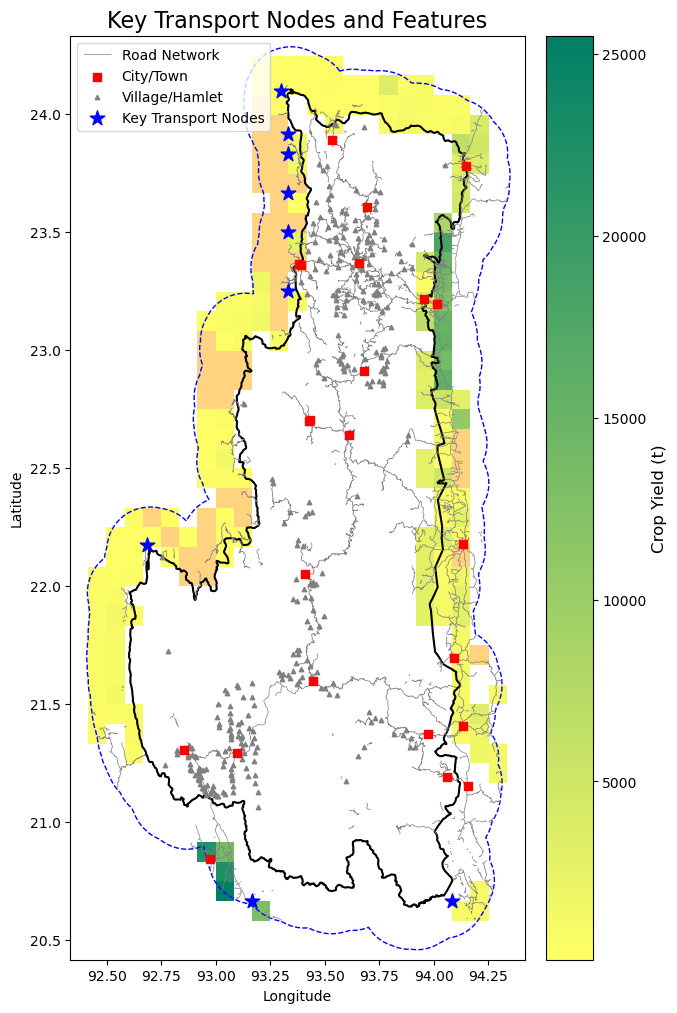

In [40]:
import osmnx as ox
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
from shapely.geometry import Point
import rasterio

# **1. 数据文件路径**
crop_tif = "E:/paper/Political Georaphy/Food/Bean/spam2020V1r0_global_production/spam2020_v1r0_global_P_mg_A.tif"
road_shp = "E:/paper/Political Georaphy/Food/accessbility/Logisticsroad.shp"
town_shp = "E:/paper/Political Georaphy/Food/Logisticstown.shp"
boundary_shp = "D:/Study/Land/data/mmr_rdsl_mimu_250k/Chin2.shp"
buffer_shp = "E:/paper/Political Georaphy/Food/Chinbuffer2.shp"
place_shp = "D:/Study/博士一年级/中缅/Chinplace.shp"

# **2. 加载数据**
# 加载粮食产值栅格
tif = rasterio.open(crop_tif)
crop_data = tif.read(1)
crop_transform = tif.transform

# 加载路网和边界数据
roads = gpd.read_file(road_shp)
towns = gpd.read_file(town_shp)
boundary = gpd.read_file(boundary_shp)
buffer = gpd.read_file(buffer_shp)
villages = gpd.read_file(place_shp)

# 加载关键枢纽点
critical_points = gpd.GeoDataFrame(
    geometry=[
        Point(93.299439, 24.100889),
        Point(92.687265, 22.175555),
        Point(93.333333, 23.666667),
        Point(93.333333, 23.500000),
        Point(93.333333, 23.250000),
        Point(93.166667, 20.666667),
        Point(93.333333, 23.916667),
        Point(93.333333, 23.833333),
        Point(94.083333, 20.666667)
    ],
    crs="EPSG:4326"
)

# **3. 可视化地图及特征**
fig, ax = plt.subplots(figsize=(14, 12))

# 绘制粮食作物栅格数据
crop_data_masked = np.ma.masked_where(crop_data <= 0, crop_data)
cmap = plt.cm.get_cmap('summer_r')
cmap.set_under(color=(255/255, 211/255, 127/255))  # 红色表示 0-100t 230/255, 117/255, 95/255
im = ax.imshow(
    crop_data_masked,
    cmap=cmap,
    extent=[
        crop_transform[2],
        crop_transform[2] + crop_transform[0] * crop_data.shape[1],
        crop_transform[5] + crop_transform[4] * crop_data.shape[0],
        crop_transform[5]
    ],
    vmin=100, vmax=np.max(crop_data),
    interpolation='nearest'
)

# 添加色标
cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Crop Yield (t)', fontsize=12)

# 绘制钦邦边界和缓冲区
boundary.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1.5, label='Chin Boundary')
buffer.plot(ax=ax, edgecolor='blue', facecolor='none', linestyle='--', linewidth=1, label='20km Buffer')

# 绘制路网
roads.plot(ax=ax, color='gray', linewidth=0.5, label='Road Network')

# 绘制居民点（区分村庄和城市）
towns.plot(ax=ax, color='red', marker='s', markersize=30, zorder=3,label='City/Town')
villages.plot(ax=ax, color='gray', marker='^', markersize=10,zorder=2, label='Village/Hamlet')

# 绘制关键枢纽点
critical_points.plot(ax=ax, color='blue', marker='*', markersize=120,zorder=2, label='Key Transport Nodes')

# **4. 图例及标题**
plt.title("Key Transport Nodes and Features", fontsize=16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(loc='upper left', fontsize=10)
plt.grid(False)

# 保存与显示
plt.savefig("E:/paper/Political Georaphy/Food/Key_Transport_Nodes_Map1.png", dpi=300)
plt.show()


C:\Users\Joey_Duwenjie\AppData\Local\Temp\ipykernel_11284\228546112.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('summer_r')


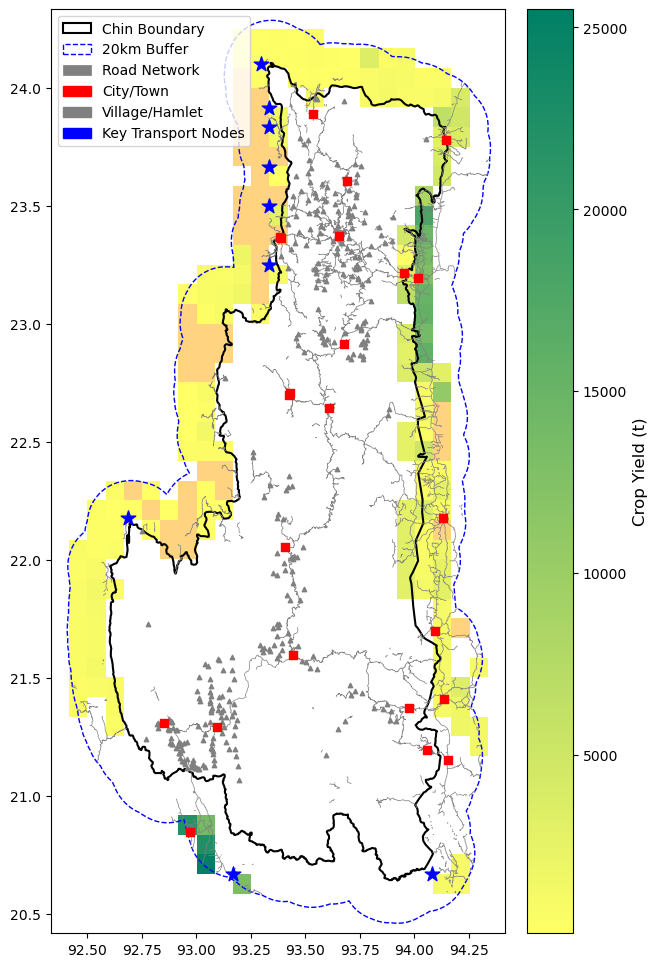

In [43]:
# **3. 可视化地图及特征**
fig, ax = plt.subplots(figsize=(14, 12))

# 绘制粮食作物栅格数据
crop_data_masked = np.ma.masked_where(crop_data <= 0, crop_data)
cmap = plt.cm.get_cmap('summer_r')
cmap.set_under(color=(255/255, 211/255, 127/255))  # 红色表示 0-100t 230/255, 117/255, 95/255
im = ax.imshow(
    crop_data_masked,
    cmap=cmap,
    extent=[
        crop_transform[2],
        crop_transform[2] + crop_transform[0] * crop_data.shape[1],
        crop_transform[5] + crop_transform[4] * crop_data.shape[0],
        crop_transform[5]
    ],
    vmin=100, vmax=np.max(crop_data),
    interpolation='nearest'
)

# 添加色标
cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Crop Yield (t)', fontsize=12)

# 绘制钦邦边界和缓冲区
boundary.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1.5)
buffer.plot(ax=ax, edgecolor='blue', facecolor='none', linestyle='--', linewidth=1)

# 绘制路网
roads.plot(ax=ax, color='gray', linewidth=0.5, label='Road Network')

# 绘制居民点（区分村庄和城市）
towns.plot(ax=ax, color='red', marker='s', markersize=30, zorder=3, label='City/Town')
villages.plot(ax=ax, color='gray', marker='^', markersize=10, zorder=2, label='Village/Hamlet')

# 绘制关键枢纽点
critical_points.plot(ax=ax, color='blue', marker='*', markersize=120, zorder=2, label='Key Transport Nodes')

# **4. 手动添加边界和缓冲区到图例**
import matplotlib.patches as mpatches

# 创建图例条目
boundary_patch = mpatches.Patch(edgecolor='black', facecolor='none', label='Chin Boundary', linewidth=1.5)
buffer_patch = mpatches.Patch(edgecolor='blue', facecolor='none', label='20km Buffer', linestyle='--', linewidth=1)

# 添加图例
plt.legend(handles=[
    boundary_patch,
    buffer_patch,
    mpatches.Patch(color='gray', linewidth=0.5, label='Road Network'),
    mpatches.Patch(color='red',  label='City/Town'),
    mpatches.Patch(color='gray',label='Village/Hamlet'),
    mpatches.Patch(color='blue',  label='Key Transport Nodes'),
], loc='upper left', fontsize=10)

# 添加标题和坐标轴标签
#plt.title("Key Transport Nodes and Features", fontsize=16)
#plt.xlabel("Longitude")
#plt.ylabel("Latitude")
plt.grid(False)

# 保存与显示
plt.savefig("E:/paper/Political Georaphy/Food/Key_Transport_Nodes_Map2.png", dpi=300)
plt.show()


In [57]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.dates as mdates
from datetime import datetime

# 设置字体为 Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

# 数据
network_data = {
    "2016": [("Arakan Army", "Paletwa", "Clashed"), ("Chin National Army", "Hakha", "Ceasefire Talks"), ("Myanmar Government", "Rakhine State", "Military Control")],
    "2017": [("Arakan Army", "Illicit Trade", "Expansion"), ("Chin Militias", "Southern Chin State", "Resistance"), ("Myanmar Government", "Tedim", "Negotiations")],
    "2018": [("Arakan Army", "Waterways Control", "Dominance"), ("Military", "Transit Outposts", "Blockade"), ("Local Activists", "Regional Autonomy", "Advocacy")],
    "2019": [("Chin State Militias", "Opium Trade", "Funding"), ("Military", "Transit Blockade", "Tensions"), ("New Council", "Decentralized Governance", "Formation")],
    "2020": [("Militias", "Aid Control", "Conflicts"), ("Military", "Southern Deployment", "Operations"), ("Local Protests", "Political Representation", "Demands")],
    "2021": [("Chin Militias", "NUG Coordination", "Alliance"), ("Military", "Airstrikes", "Attacks"), ("Spring Revolution", "Widespread Resistance", "Mobilization")],
    "2022": [("Arakan Army", "Paletwa Control", "Occupation"), ("Chin Council", "Joint Resource Talks", "Negotiations"), ("Border Tensions", "Refugee Crisis", "Escalation")],
    "2023": [("New Council", "Self-Governance", "Initiative"), ("Arakan Army", "Border Clashes", "Skirmishes"), ("Military", "Aerial Bombings", "Intensification")],
}

# 创建网络图
network_graph = nx.DiGraph()

for year, connections in network_data.items():
    for source, target, interaction in connections:
        network_graph.add_edge(source, target, year=year, interaction=interaction)

# 绘制网络图
plt.figure(figsize=(14, 12))
pos = nx.spring_layout(network_graph, seed=42)

# 根据年份对边进行分类并绘制，动态生成图例信息
edge_labels = []
for year, color in edge_colors.items():
    edges = [(u, v) for u, v, d in network_graph.edges(data=True) if d["year"] == year]
    nx.draw_networkx_edges(network_graph, pos, edgelist=edges, edge_color=color, alpha=0.7, label=f"{year}")
    edge_labels.append((year, color))  # 动态生成年份和颜色的映射

# 绘制图例
handles = [plt.Line2D([0], [0], color=color, lw=2, label=str(year)) for year, color in edge_labels]
plt.legend(handles=handles, loc="upper left", fontsize=10, title="Year", title_fontsize=12)


# 绘制节点和标签
nx.draw_networkx_nodes(network_graph, pos, node_size=450, node_color="skyblue", alpha=0.9)
nx.draw_networkx_labels(network_graph, pos, font_size=10, font_color="black")

# 添加图例和标题
plt.legend(edge_colors.keys(), loc="upper left", fontsize=10, title="Year", title_fontsize=12)
plt.axis("off")
plt.savefig("E:/paper/Political Georaphy/Food/network_plot.jpg", format="jpg")
plt.close()

# 时间轴数据
timeline_data = [
    ("2016-01", "Arakan Army clashed in Paletwa"),
    ("2016-05", "CNF initiated ceasefire talks"),
    ("2017-03", "CNF split over govt alignment"),
    ("2017-07", "Arakan Army expanded illicit trade"),
    ("2018-04", "Arakan Army controlled waterways"),
    ("2019-02", "Militias relied on opium trade"),
    ("2020-03", "COVID-19 escalated resource conflicts"),
    ("2021-02", "Spring Revolution resistance"),
    ("2022-01", "Arakan Army solidified Paletwa control"),
    ("2023-03", "New council for self-governance"),
    ("2023-12", "Military aerial bombings increased"),
]

# 绘制时间轴
dates = [datetime.strptime(d[0], "%Y-%m") for d in timeline_data]
events = [d[1] for d in timeline_data]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates, range(len(dates)), marker="o", color="blue", linestyle="-")
for i, (date, event) in enumerate(zip(dates, events)):
    ax.text(date, i, f" {event}", verticalalignment="center", fontsize=9, color="black")

# 时间轴格式化
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xlabel("Year")
plt.ylabel("Event Index")
plt.grid(visible=True, linestyle="--", alpha=0.6)
plt.savefig("E:/paper/Political Georaphy/Food/timeline_plot.jpg", format="jpg")
plt.close()

# 组合两张图
fig, axs = plt.subplots(1, 2, figsize=(20, 10))

# 加载并显示网络图
network_img = plt.imread("E:/paper/Political Georaphy/Food/network_plot.jpg")
axs[0].imshow(network_img)
axs[0].axis("off")

# 加载并显示时间轴
timeline_img = plt.imread("E:/paper/Political Georaphy/Food/timeline_plot.jpg")
axs[1].imshow(timeline_img)
axs[1].axis("off")

# 保存组合图
plt.savefig("E:/paper/Political Georaphy/Food/combined_plots.jpg", format="jpg",dpi=600)
plt.close()


In [63]:
import networkx as nx

# 数据
network_data = {
    "2016": [("Arakan Army", "Paletwa", "Clashed"), ("Chin National Army", "Hakha", "Ceasefire Talks"), ("Myanmar Government", "Rakhine State", "Military Control")],
    "2017": [("Arakan Army", "Illicit Trade", "Expansion"), ("Chin Militias", "Southern Chin State", "Resistance"), ("Myanmar Government", "Tedim", "Negotiations")],
    "2018": [("Arakan Army", "Waterways Control", "Dominance"), ("Military", "Transit Outposts", "Blockade"), ("Local Activists", "Regional Autonomy", "Advocacy")],
    "2019": [("Chin State Militias", "Opium Trade", "Funding"), ("Military", "Transit Blockade", "Tensions"), ("New Council", "Decentralized Governance", "Formation")],
    "2020": [("Militias", "Aid Control", "Conflicts"), ("Military", "Southern Deployment", "Operations"), ("Local Protests", "Political Representation", "Demands")],
    "2021": [("Chin Militias", "NUG Coordination", "Alliance"), ("Military", "Airstrikes", "Attacks"), ("Spring Revolution", "Widespread Resistance", "Mobilization")],
    "2022": [("Arakan Army", "Paletwa Control", "Occupation"), ("Chin Council", "Joint Resource Talks", "Negotiations"), ("Border Tensions", "Refugee Crisis", "Escalation")],
    "2023": [("New Council", "Self-Governance", "Initiative"), ("Arakan Army", "Border Clashes", "Skirmishes"), ("Military", "Aerial Bombings", "Intensification")],
}

# 创建网络图
network_graph = nx.DiGraph()

for year, connections in network_data.items():
    for source, target, interaction in connections:
        network_graph.add_edge(source, target, year=year, interaction=interaction)

# 导出为 GraphML 文件
output_file = "E:/paper/Political Georaphy/Chin_State_Interactions_2016_2023.graphml"
nx.write_graphml(network_graph, output_file)

print(f"Network exported successfully to {output_file}")


Network exported successfully to E:/paper/Political Georaphy/Chin_State_Interactions_2016_2023.graphml
